In [6]:
import sys
import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA version used by PyTorch:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU count:", torch.cuda.device_count())
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Current CUDA device:", torch.cuda.current_device())

/opt/conda/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.8.12 (default, Oct 12 2021, 13:49:34) 
[GCC 7.5.0]
PyTorch: 1.11.0
CUDA version used by PyTorch: 11.3
CUDA available: True
GPU count: 1
GPU name: NVIDIA RTX A5000
Current CUDA device: 0


In [ ]:
print("hello")

In [3]:
!pwd
!df -h /workspace

/workspace
Filesystem                   Size  Used Avail Use% Mounted on
mfs#us-il-1.runpod.net:9421  671T  404T  268T  61% /workspace


In [18]:
from PIL import Image, ImageDraw
import pandas as pd
import cv2
import os
import numpy as np
from ultralytics import YOLO
from tqdm import tqdm
import glob
import torch
import argparse
import torch.nn.functional as F
import torch.nn as nn
from shapely.geometry import Polygon
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou

def get_iou_polygon(polygonA, polygonB):
    # This function would calculate the IoU between two polygons.
    polyA = Polygon([(polygonA[i], polygonA[i + 1]) for i in range(0, len(polygonA), 2)])
    polyB = Polygon([(polygonB[i], polygonB[i + 1]) for i in range(0, len(polygonB), 2)])
    iou = polyA.intersection(polyB).area / polyA.union(polyB).area
    return iou

def nms_classwise(df):
    def nms_single_class(df_class):
        elements = df_class.to_dict('records')
        elements.sort(key=lambda x: x['confidence'], reverse=True)
        selected_elements = []

        for current in elements:
            # Correctly using list comprehension for creating a list of vertices for the current polygon
            current_polygon = [val for i in range(4) for val in (current[f'x{i+1}'], current[f'y{i+1}'])]

            overlap = False
            for selected in selected_elements:
                # Similarly constructing the polygon vertices list for the selected element
                selected_polygon = [val for i in range(4) for val in (selected[f'x{i+1}'], selected[f'y{i+1}'])]

                if get_iou_polygon(current_polygon, selected_polygon) > 0.3:  # Using the corrected polygon IoU function
                    overlap = True
                    break

            if not overlap:
                selected_elements.append(current)

        return pd.DataFrame(selected_elements)

    grouped = df.groupby('label')
    nms_dfs = [nms_single_class(group) for _, group in grouped]
    return pd.concat(nms_dfs, ignore_index=True)

def get_symmetrical_angle_ranges_with_median(df):
    pivot = 90
    # Adjust all angles to be within 0-90 based on their symmetry around the pivot
    df['adjusted_angle'] = df['angle'].apply(lambda x: x if x <= pivot else 180 - x)
    bin_counts = np.histogram(df['adjusted_angle'], bins=[0, 15, 30, 45, 60, 75, 90])[0]
    top_two_bins = bin_counts.argsort()[-2:][::-1]  # Get indexes of the two highest bins
    total_count_top_two_bins = sum(bin_counts[top_two_bins])
    if total_count_top_two_bins / len(df) * 100 > 80:
        median_rotation = np.median(df['adjusted_angle'])
        return True, median_rotation
    else:
        return False, None


def get_yolo_boxes(image_path, cropped_img = None, dump_images=False, conf_thresh = .1, estimate_rotation = True, dump_txt = False):
    try:
        im = np.array(cropped_img)
        im = im[:, :, ::-1].copy()
    except:
        im = cv2.imread(image_path)
    pageheight, pagewidth= im.shape[0], im.shape[1]
    predictions = det_model(im, imgsz=800, conf=0.05, max_det=10000, verbose=False)
    xywhr =  predictions[0].obb.xywhr.tolist()
    xyxyxyxy = predictions[0].obb.xyxyxyxy.tolist()
    xyxy = predictions[0].obb.xyxy.tolist()
    classes = predictions[0].obb.cls.tolist()
    confidence = predictions[0].obb.conf.tolist()
    names = [
        "box", "table", "column", "header",
        "signature", "figure", "paragraph", "logo", "kv", "stamp"
    ] # Get class names
    name_to_id = {name: i for i, name in enumerate(names)}

    # Color codes for each label
    color_codes = {
        "box": (255, 0, 0),  # Blue
        "header": (255, 0, 0),  # Blue
        "table": (0, 255, 0),  # Green
        "column": (0, 255, 0),  # Green
        "logo": (0, 0, 255),  # Red
        "signature": (0, 255, 255),  # Yellow
        "stamp": (0, 0, 0),  # Black
        # Default color for other labels (optional)
        "default": (255, 255, 255)  # White
    }
    if dump_images:
        # Check if results directory exists, if not, create it
        if not os.path.exists('results'):
            os.makedirs('results')
        # Make a copy of the image to draw on
        im_copy = im.copy()
    df_data = []
    for i, a in enumerate(xywhr):
        centroid_x, centroid_y, width, height, radians = a
        x1, y1 = int(xyxyxyxy[i][0][0]), int(xyxyxyxy[i][0][1])
        x2, y2 = int(xyxyxyxy[i][1][0]), int(xyxyxyxy[i][1][1])
        x3, y3 = int(xyxyxyxy[i][2][0]), int(xyxyxyxy[i][2][1])
        x4, y4 = int(xyxyxyxy[i][3][0]), int(xyxyxyxy[i][3][1])

        label_id = int(classes[i])
        label_name = names[label_id]
        conf = confidence[i]

        if conf > conf_thresh:
            df_data.append({
                "x1": int(x1), "y1": int(y1),
                "x2": int(x2), "y2": int(y2),
                "x3": int(x3), "y3": int(y3),
                "x4": int(x4), "y4": int(y4),
                "centroid_x": centroid_x, "centroid_y": centroid_y,
                "width": width, "height": height, "angle": radians * 180 / 3.14159,
                "label": label_name, "confidence": conf
            })

    df = pd.DataFrame(df_data, columns=['x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'x4', 'y4', 'centroid_x', 'centroid_y', 'width', 'height', 'angle', 'label', 'confidence'])

    if len(df) > 0:
        filtered_df = nms_classwise(df)
        if dump_images and len(df) > 0:
        # Iterate over each row in the filtered DataFrame to draw the polygons
            for index, row in filtered_df.iterrows():
            # Extract points for the current polygon
                pts = np.array([(row['x1'], row['y1']), (row['x2'], row['y2']),
                            (row['x3'], row['y3']), (row['x4'], row['y4'])], np.int32)
            # Reshape points in the form required by polylines
                pts = pts.reshape((-1, 1, 2))

            # Use specified color or default if not specified
                color = color_codes.get(row['label'], color_codes["default"])

            # Draw the polygon on the image
                cv2.polylines(im_copy, [pts], isClosed=True, color=color, thickness=2)

        # Save the modified image
            output_image_path = os.path.join('results', os.path.basename(image_path))
            cv2.imwrite(output_image_path, im_copy)
    else:
        return df, 0
    final_rotation = 0
    yolo_data = []
    if estimate_rotation:
        has_rotation, median_rotation = get_symmetrical_angle_ranges_with_median(df)
        final_rotation = infer_document_orientation(image_path, filtered_df, median_rotation)
    return filtered_df, final_rotation


def infer_document_orientation(image_path, filtered_df, median_rotation):
    # Load the image to get its dimensions
    document_width, document_height = Image.open(image_path).size

    # Function to infer orientation based on sorted elements (logos or headers)
    def infer_orientation_from_elements(elements):
        if len(elements) > 0:
            # Sort elements first by confidence (descending) and then by centroid_y (ascending)
            valid_element = elements.sort_values(by=['confidence', 'centroid_y'], ascending=[False, True]).iloc[0]

            # Define margins and alignment tolerance
            left_margin = document_width * 0.1
            alignment_tolerance = document_width * 0.1  # 10% of document width

            # Check alignment and position based on median_rotation for orientation clues
            if median_rotation < 25:  # Potential orientations: 0 or 180 degrees
                if valid_element['centroid_y'] < document_height / 3:
                    return median_rotation  # Element at top, suggesting 0 degrees rotation
                elif valid_element['centroid_y'] > 2 * document_height / 3:
                    return 180 - median_rotation  # Element at bottom, suggesting 180 degrees rotation
            elif median_rotation > 75:
                if valid_element['centroid_x'] < document_width / 3:
                    return 90  # Counter-clockwise 90 degrees
                elif valid_element['centroid_x'] > 2 * document_width / 3:
                    return -90  # Clockwise 90 degrees
        return -1  # Default return value if no orientation is inferred

    # Try with logos first
    logos = filtered_df[filtered_df['label'] == 'logo']
    orientation = infer_orientation_from_elements(logos)

    # If no conclusive orientation from logos, try with headers
    if orientation == -1:
        headers = filtered_df[filtered_df['label'] == 'header']
        orientation = infer_orientation_from_elements(headers)

    return orientation
def get_document_roi(yolo_boxes_df, image_height, image_width):
    # Initialize default crop coordinates to image boundaries
    x1, x2 = 0, image_width
    y1, y2 = 0, image_height

    # Update x1 and x2 based on 'table' detections
    table_df = yolo_boxes_df[yolo_boxes_df['label'] == 'table']
    if not table_df.empty:
        x1 = table_df[['x1', 'x2', 'x3', 'x4']].min().min()
        x2 = table_df[['x1', 'x2', 'x3', 'x4']].max().max()

    # Update y1 based on 'stamp' or 'header' detections
    logo_header_df = yolo_boxes_df[yolo_boxes_df['label'].isin(['logo', 'header'])]
    if not logo_header_df.empty:
        y1 = logo_header_df[['y1', 'y2', 'y3', 'y4']].min().min()

    # Update y2 based on 'stamp' detections
    stamp_df = yolo_boxes_df[yolo_boxes_df['label'] == 'stamp']
    if not stamp_df.empty:
        y2 = stamp_df[['y1', 'y2', 'y3', 'y4']].max().max()


    # Apply a margin around the detected ROI
    MARGIN = 0.15
    x1 = max(int(x1 - MARGIN * (x2 - x1)), 0)
    x2 = min(int(x2 + MARGIN * (x2 - x1)), image_width)
    y1 = max(int(y1 - MARGIN * (y2 - y1)), 0)
    y2 = min(int(y2 + MARGIN * (y2 - y1)), image_height)

    if x1 >= image_width //2:
        x1 = 0
    if y1 > image_height //4:
        y1 = 0
    if x2 < image_width //2:
        x2 = image_width
    if y2 < 3*image_height //4:
        y2 = image_height
    return x1, y1, x2, y2
def rotate_image(image_pil, angle):
    # Convert PIL image to OpenCV format
    image = cv2.cvtColor(np.array(image_pil), cv2.COLOR_RGB2BGR)

    # Get the dimensions of the image
    h, w = image.shape[:2]

    # Calculate the center of the image
    center = (w / 2, h / 2)

    # Calculate the rotation matrix
    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    # Calculate the cosine and sine of the rotation angle (in radians)
    angle_rad = np.deg2rad(angle)
    cos_a = np.abs(np.cos(angle_rad))
    sin_a = np.abs(np.sin(angle_rad))

    # Compute the new bounding dimensions of the image
    new_w = int((h * sin_a) + (w * cos_a))
    new_h = int((h * cos_a) + (w * sin_a))

    # Adjust the rotation matrix to consider translation
    M[0, 2] += (new_w / 2) - center[0]
    M[1, 2] += (new_h / 2) - center[1]

    # Perform the actual rotation

    rotated = cv2.warpAffine(image, M, (new_w, new_h))

    # Convert the OpenCV image back to PIL format
    rotated_pil = Image.fromarray(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))

    # Return the PIL image
    return rotated_pil

def crop_document(image_path):
    document_image = Image.open(image_path)
    document_width, document_height = document_image.size
    df, rotation = get_yolo_boxes(image_path, document_image)
    # Rotation handling
    if rotation == -1:
        return -1, document_image.convert('RGB')
    elif rotation == -90 or rotation == 90:
        # document_image = document_image.rotate(-rotation, expand=True)
        document_image = rotate_image(document_image, -rotation)
        df, _ = get_yolo_boxes(image_path, document_image, estimate_rotation = False)
    elif rotation > 150:
        # document_image = document_image.rotate(rotation, expand=True)
        document_image = rotate_image(document_image, rotation)
        df, _ = get_yolo_boxes(image_path, document_image, estimate_rotation = False)
        # Rotate image 180 degrees

    # After rotation, adjust dimensions if necessary
    if rotation in [-90, 90, 180]:
        document_width, document_height = document_image.size
    # Filter for relevant labels before passing to get_document_roi
    relevant_labels = ['stamp', 'table', 'logo', 'header']
    relevant_df = df[df['label'].isin(relevant_labels)]

    # Use get_document_roi to calculate the crop boundaries if relevant detections are present
    if not relevant_df.empty:
        crop_x1, crop_y1, crop_x2, crop_y2 = get_document_roi(relevant_df, document_height, document_width)
        cropped_img = document_image.crop((crop_x1, crop_y1, crop_x2, crop_y2))
    else:
        # If no relevant detections, use the full image
        crop_x1, crop_y1, crop_x2, crop_y2 = 0, 0, document_width, document_height
        cropped_img = document_image.crop((crop_x1, crop_y1, crop_x2, crop_y2))
        return 0, cropped_img.convert('RGB')
    # Crop and return the image

    return 0, cropped_img.convert('RGB')
def conv3x3(in_channels, out_channels, kernel_size, stride=1):
    return nn.Conv2d(
        in_channels,
        out_channels,
        kernel_size=kernel_size,
        stride=stride,
        padding=kernel_size // 2,
    )


def dilated_conv_bn_act(in_channels, out_channels, act_fn, BatchNorm, dilation):
    model = nn.Sequential(
        nn.Conv2d(
            in_channels,
            out_channels,
            bias=False,
            kernel_size=3,
            stride=1,
            padding=dilation,
            dilation=dilation,
        ),
        BatchNorm(out_channels),
        act_fn,
    )
    return model


def dilated_conv(in_channels, out_channels, kernel_size, dilation, stride=1):
    model = nn.Sequential(
        nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=dilation * (kernel_size // 2),
            dilation=dilation,
        )
    )
    return model


class ResidualBlockWithDilation(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        BatchNorm,
        kernel_size,
        stride=1,
        downsample=None,
        is_activation=True,
        is_top=False,
    ):
        super(ResidualBlockWithDilation, self).__init__()
        self.stride = stride
        self.downsample = downsample
        self.is_activation = is_activation
        self.is_top = is_top
        if self.stride != 1 or self.is_top:
            self.conv1 = conv3x3(in_channels, out_channels, kernel_size, self.stride)
            self.conv2 = conv3x3(out_channels, out_channels, kernel_size)
        else:
            self.conv1 = dilated_conv(in_channels, out_channels, kernel_size, dilation=3)
            self.conv2 = dilated_conv(out_channels, out_channels, kernel_size, dilation=3)

        self.bn1 = BatchNorm(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.bn2 = BatchNorm(out_channels)

    def forward(self, x):
        residual = x
        if self.downsample is not None:
            residual = self.downsample(x)

        out1 = self.relu(self.bn1(self.conv1(x)))
        out2 = self.bn2(self.conv2(out1))

        out2 += residual
        out = self.relu(out2)
        return out


class ResnetStraight(nn.Module):
    def __init__(
        self,
        num_filter,
        map_num,
        BatchNorm,
        block_nums=[3, 4, 6, 3],
        block=ResidualBlockWithDilation,
        kernel_size=5,
        stride=[1, 1, 2, 2],
    ):
        super(ResnetStraight, self).__init__()
        self.in_channels = num_filter * map_num[0]
        self.stride = stride
        self.relu = nn.ReLU(inplace=True)
        self.block_nums = block_nums
        self.kernel_size = kernel_size

        self.layer1 = self.blocklayer(
            block,
            num_filter * map_num[0],
            self.block_nums[0],
            BatchNorm,
            kernel_size=self.kernel_size,
            stride=self.stride[0],
        )
        self.layer2 = self.blocklayer(
            block,
            num_filter * map_num[1],
            self.block_nums[1],
            BatchNorm,
            kernel_size=self.kernel_size,
            stride=self.stride[1],
        )
        self.layer3 = self.blocklayer(
            block,
            num_filter * map_num[2],
            self.block_nums[2],
            BatchNorm,
            kernel_size=self.kernel_size,
            stride=self.stride[2],
        )

    def blocklayer(self, block, out_channels, block_nums, BatchNorm, kernel_size, stride=1):
        downsample = None
        if (stride != 1) or (self.in_channels != out_channels):
            downsample = nn.Sequential(
                conv3x3(
                    self.in_channels,
                    out_channels,
                    kernel_size=kernel_size,
                    stride=stride,
                ),
                BatchNorm(out_channels),
            )

        layers = []
        layers.append(
            block(
                self.in_channels,
                out_channels,
                BatchNorm,
                kernel_size,
                stride,
                downsample,
                is_top=True,
            )
        )
        self.in_channels = out_channels
        for i in range(1, block_nums):
            layers.append(
                block(
                    out_channels,
                    out_channels,
                    BatchNorm,
                    kernel_size,
                    is_activation=True,
                    is_top=False,
                )
            )

        return nn.Sequential(*layers)

    def forward(self, x):
        out1 = self.layer1(x)
        out2 = self.layer2(out1)
        out3 = self.layer3(out2)
        return out3


class UVDocnet(nn.Module):
    def __init__(self, num_filter, kernel_size=5):
        super(UVDocnet, self).__init__()
        self.num_filter = num_filter
        self.in_channels = 3
        self.kernel_size = kernel_size
        self.stride = [1, 2, 2, 2]

        BatchNorm = nn.BatchNorm2d
        act_fn = nn.ReLU(inplace=True)
        map_num = [1, 2, 4, 8, 16]

        self.resnet_head = nn.Sequential(
            nn.Conv2d(
                self.in_channels,
                self.num_filter * map_num[0],
                bias=False,
                kernel_size=self.kernel_size,
                stride=2,
                padding=self.kernel_size // 2,
            ),
            BatchNorm(self.num_filter * map_num[0]),
            act_fn,
            nn.Conv2d(
                self.num_filter * map_num[0],
                self.num_filter * map_num[0],
                bias=False,
                kernel_size=self.kernel_size,
                stride=2,
                padding=self.kernel_size // 2,
            ),
            BatchNorm(self.num_filter * map_num[0]),
            act_fn,
        )

        self.resnet_down = ResnetStraight(
            self.num_filter,
            map_num,
            BatchNorm,
            block_nums=[3, 4, 6, 3],
            block=ResidualBlockWithDilation,
            kernel_size=self.kernel_size,
            stride=self.stride,
        )

        map_num_i = 2
        self.bridge_1 = nn.Sequential(
            dilated_conv_bn_act(
                self.num_filter * map_num[map_num_i],
                self.num_filter * map_num[map_num_i],
                act_fn,
                BatchNorm,
                dilation=1,
            )
        )

        self.bridge_2 = nn.Sequential(
            dilated_conv_bn_act(
                self.num_filter * map_num[map_num_i],
                self.num_filter * map_num[map_num_i],
                act_fn,
                BatchNorm,
                dilation=2,
            )
        )

        self.bridge_3 = nn.Sequential(
            dilated_conv_bn_act(
                self.num_filter * map_num[map_num_i],
                self.num_filter * map_num[map_num_i],
                act_fn,
                BatchNorm,
                dilation=5,
            )
        )

        self.bridge_4 = nn.Sequential(
            *[
                dilated_conv_bn_act(
                    self.num_filter * map_num[map_num_i],
                    self.num_filter * map_num[map_num_i],
                    act_fn,
                    BatchNorm,
                    dilation=d,
                )
                for d in [8, 3, 2]
            ]
        )

        self.bridge_5 = nn.Sequential(
            *[
                dilated_conv_bn_act(
                    self.num_filter * map_num[map_num_i],
                    self.num_filter * map_num[map_num_i],
                    act_fn,
                    BatchNorm,
                    dilation=d,
                )
                for d in [12, 7, 4]
            ]
        )

        self.bridge_6 = nn.Sequential(
            *[
                dilated_conv_bn_act(
                    self.num_filter * map_num[map_num_i],
                    self.num_filter * map_num[map_num_i],
                    act_fn,
                    BatchNorm,
                    dilation=d,
                )
                for d in [18, 12, 6]
            ]
        )

        self.bridge_concat = nn.Sequential(
            nn.Conv2d(
                self.num_filter * map_num[map_num_i] * 6,
                self.num_filter * map_num[2],
                bias=False,
                kernel_size=1,
                stride=1,
                padding=0,
            ),
            BatchNorm(self.num_filter * map_num[2]),
            act_fn,
        )

        self.out_point_positions2D = nn.Sequential(
            nn.Conv2d(
                self.num_filter * map_num[2],
                self.num_filter * map_num[0],
                bias=False,
                kernel_size=self.kernel_size,
                stride=1,
                padding=self.kernel_size // 2,
                padding_mode="reflect",
            ),
            BatchNorm(self.num_filter * map_num[0]),
            nn.PReLU(),
            nn.Conv2d(
                self.num_filter * map_num[0],
                2,
                kernel_size=self.kernel_size,
                stride=1,
                padding=self.kernel_size // 2,
                padding_mode="reflect",
            ),
        )

        self.out_point_positions3D = nn.Sequential(
            nn.Conv2d(
                self.num_filter * map_num[2],
                self.num_filter * map_num[0],
                bias=False,
                kernel_size=self.kernel_size,
                stride=1,
                padding=self.kernel_size // 2,
                padding_mode="reflect",
            ),
            BatchNorm(self.num_filter * map_num[0]),
            nn.PReLU(),
            nn.Conv2d(
                self.num_filter * map_num[0],
                3,
                kernel_size=self.kernel_size,
                stride=1,
                padding=self.kernel_size // 2,
                padding_mode="reflect",
            ),
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_normal_(m.weight, gain=0.2)
            if isinstance(m, nn.ConvTranspose2d):
                assert m.kernel_size[0] == m.kernel_size[1]
                nn.init.xavier_normal_(m.weight, gain=0.2)

    def forward(self, x):
        resnet_head = self.resnet_head(x)
        resnet_down = self.resnet_down(resnet_head)
        bridge_1 = self.bridge_1(resnet_down)
        bridge_2 = self.bridge_2(resnet_down)
        bridge_3 = self.bridge_3(resnet_down)
        bridge_4 = self.bridge_4(resnet_down)
        bridge_5 = self.bridge_5(resnet_down)
        bridge_6 = self.bridge_6(resnet_down)
        bridge_concat = torch.cat([bridge_1, bridge_2, bridge_3, bridge_4, bridge_5, bridge_6], dim=1)
        bridge = self.bridge_concat(bridge_concat)

        out_point_positions2D = self.out_point_positions2D(bridge)
        out_point_positions3D = self.out_point_positions3D(bridge)

        return out_point_positions2D, out_point_positions3D
def bilinear_unwarping(warped_img, point_positions, img_size):
    upsampled_grid = F.interpolate(
        point_positions, size=(img_size[1], img_size[0]), mode="bilinear", align_corners=True
    )
    unwarped_img = F.grid_sample(warped_img, upsampled_grid.transpose(1, 2).transpose(2, 3), align_corners=True)

    return unwarped_img
def load_rec_model(ckpt_path):
    """
    Load UVDocnet model.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = UVDocnet(num_filter=32, kernel_size=5)
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    model.to(device)
    model.eval()
    return model

def unwarp_img(model, device, image, final_doc_size):
    IMG_SIZE = [488, 712]
    model.eval()
    img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype(np.float32) / 255
    inp = torch.from_numpy(cv2.resize(img, IMG_SIZE).transpose(2, 0, 1)).unsqueeze(0)

    # Make prediction
    inp = inp.to(device)
    point_positions2D, _ = model(inp)

    unwarped = bilinear_unwarping(
        warped_img=torch.from_numpy(img.transpose(2, 0, 1)).unsqueeze(0).to(device),
        point_positions=torch.unsqueeze(point_positions2D[0], dim=0),
        img_size=tuple(final_doc_size),
    )
    unwarped = (unwarped[0].detach().cpu().numpy().transpose(1, 2, 0) * 255).astype(np.uint8)

    # Save result
    unwarped_BGR = cv2.cvtColor(unwarped, cv2.COLOR_RGB2BGR)

    return unwarped_BGR
def check_blur_fourier(image_path):
    image = cv2.imread(image_path, 0)  # Read in grayscale
    if image is None:
        return "Image not found or path is incorrect."

    # Compute the FFT of the image
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20*np.log(np.abs(fshift))
    threshold = 130  # This is a hypothetical threshold and needs to be tuned
    mean_val = np.mean(magnitude_spectrum)
    if mean_val < threshold:
        return False  # Likely blurred
    else:
        return True  # Likely not blurred
def document_rectification(image_file_path, final_doc_size=(1200, 1700), save_img=True,
                           path_to_save='./rectified/', unwrap = True):
    valid, cropped_img = crop_document(image_file_path)
    # if not check_blur_fourier(image_file_path):
    #     print('failed ::: ', image_file_path)
    #     return [], []
    if valid == -1:
        print('failed ::: ', image_file_path)
        return [], []
    cropped_img = np.array(cropped_img)[:, :, ::-1]
    if unwrap:
        unwarped_img = unwarp_img(rec_model, device, cropped_img, final_doc_size)
    else:
        unwarped_img = cropped_img

    if save_img:
        output_image_path = os.path.join(path_to_save, os.path.basename(image_file_path))
        cv2.imwrite(output_image_path, unwarped_img)

    return cropped_img, unwarped_img

det_model = YOLO("./rotation_final.pt")
rec_model = load_rec_model('./rect_model.pkl')


In [ ]:
ls

In [15]:
!ls

images_unwrap_process.csv  requirements-freeze.txt  rotation_final.pt
rect_model.pkl		   requirements.txt	    setup-notes.txt
requirements-clean.txt	   rotation_22may.pt	    unwrap.ipynb


In [8]:
# Test function on a single image
cropped_img, unwarped_img = document_rectification("./test_images/19-41-08-011.jpg", save_img=True, unwrap=True)


FileNotFoundError: [Errno 2] No such file or directory: './test_images/19-41-08-011.jpg'

In [17]:
import os
import cv2
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed

BASE = "../test_images/batch_test"   # <- single source of truth for paths

def process_image(args):
    index, row = args
    image_file_path = f"{BASE}/{row['jpg_filepath']}"
    polling_unit_code = row['polling_unit_code']
    blurred = row['blurred']

    state_code, lga_code, ward_code, polling_unit_id = polling_unit_code.split('/')
    original_file_name = os.path.splitext(os.path.basename(image_file_path))[0]

    new_path_unwrap = f"{BASE}/unwrapped_files_jpg/state_{state_code}/lga_{lga_code}/ward_{ward_code}/{original_file_name}_unwrap.jpg"
    new_path_crop   = f"{BASE}/cropped_files_jpg/state_{state_code}/lga_{lga_code}/ward_{ward_code}/{original_file_name}_crop.jpg"

    os.makedirs(os.path.dirname(new_path_unwrap), exist_ok=True)
    os.makedirs(os.path.dirname(new_path_crop), exist_ok=True)

    if blurred:
        return index, 'blurred'

    try:
        cropped_img, unwarped_img = document_rectification(image_file_path, save_img=False, unwrap=True)
        if len(cropped_img) == 0 and len(unwarped_img) == 0:
            return index, 'rotate failure'
        cv2.imwrite(new_path_unwrap, unwarped_img)
        cv2.imwrite(new_path_crop, cropped_img)
        return index, 'Success'
    except Exception as e:
        print(f"Error processing {image_file_path}: {str(e)}")
        return index, str(e)


csv_file = f"{BASE}/csv/images_unwrap_process.csv"
if os.path.exists(csv_file):
    print('resuming from existing progress file')
    df = pd.read_csv(csv_file)
else:
    print('starting fresh')
    df_all = pd.read_csv(f"{BASE}/csv/final_processed_files_img.csv")
    df = df_all.loc[:, ['jpg_filepath', 'polling_unit_code', 'blurred']].copy()
    df.reset_index(inplace=True, drop=True)
    df['status'] = pd.NA

with ThreadPoolExecutor() as executor:
    unprocessed_rows = df[df['status'].isna() & ~df['jpg_filepath'].isna()].iterrows()
    futures = []
    batch_size = 1000
    processed_count = 0

    while True:
        batch = []
        for _ in range(batch_size):
            try:
                batch.append(next(unprocessed_rows))
            except StopIteration:
                break
        if not batch:
            break

        futures.extend(executor.submit(process_image, args) for args in batch)

        for future in as_completed(futures):
            index, status = future.result()
            df.at[index, 'status'] = status
            processed_count += 1

        df.to_csv(csv_file, index=False)
        print(f"Processed {processed_count} files. Results saved to {csv_file}")

df.to_csv(csv_file, index=False)
print(f"Processing completed. Total files processed: {processed_count}")

resuming from existing progress file
Processing completed. Total files processed: 0


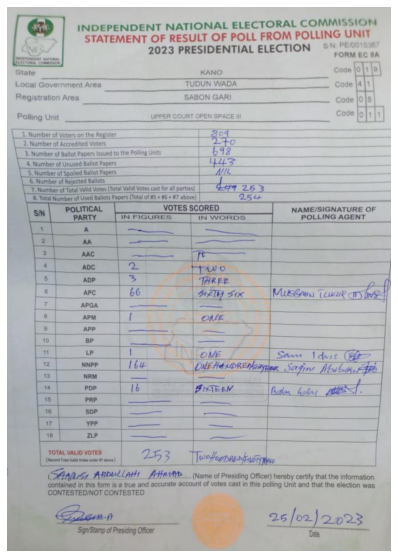

In [11]:
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(8, 10))
plt.imshow(cv2.cvtColor(unwarped_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [2]:
import pandas as pd
df=pd.read_csv('../test_images/batch_test/csv/final_processed_files_img.csv')

In [3]:
df.head()

,jpg_filepath,polling_unit_code,blurred
0,consolidated_files_jpg/state_22/lga_05/ward_10...,22/05/10/028,False
1,consolidated_files_jpg/state_22/lga_05/ward_10...,22/05/10/016,False
2,consolidated_files_jpg/state_22/lga_05/ward_10...,22/05/10/047,False
3,consolidated_files_jpg/state_22/lga_05/ward_10...,22/05/10/010,False
4,consolidated_files_jpg/state_02/lga_14/ward_04...,02/14/04/023,False


In [20]:
import os
import cv2
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed

BASE = "../test_images/batch_test"   # <- single source of truth for paths

def process_image(args):
    index, row = args
    image_file_path = f"{BASE}/{row['jpg_filepath']}"
    polling_unit_code = row['polling_unit_code']
    blurred = row['blurred']

    state_code, lga_code, ward_code, polling_unit_id = polling_unit_code.split('/')
    original_file_name = os.path.splitext(os.path.basename(image_file_path))[0]

    new_path_unwrap = f"{BASE}/unwrapped_files_jpg/state_{state_code}/lga_{lga_code}/ward_{ward_code}/{original_file_name}_unwrap.jpg"
    new_path_crop   = f"{BASE}/cropped_files_jpg/state_{state_code}/lga_{lga_code}/ward_{ward_code}/{original_file_name}_crop.jpg"

    os.makedirs(os.path.dirname(new_path_unwrap), exist_ok=True)
    os.makedirs(os.path.dirname(new_path_crop), exist_ok=True)

    if blurred:
        return index, 'blurred'

    try:
        cropped_img, unwarped_img = document_rectification(image_file_path, save_img=False, unwrap=True)
        if len(cropped_img) == 0 and len(unwarped_img) == 0:
            return index, 'rotate failure'
        cv2.imwrite(new_path_unwrap, unwarped_img)
        cv2.imwrite(new_path_crop, cropped_img)
        return index, 'Success'
    except Exception as e:
        print(f"Error processing {image_file_path}: {str(e)}")
        return index, str(e)


csv_file = f"{BASE}/csv/images_unwrap_process.csv"
if os.path.exists(csv_file):
    print('resuming from existing progress file')
    df = pd.read_csv(csv_file)
else:
    print('starting fresh')
    df_all = pd.read_csv(f"{BASE}/csv/final_processed_files_img.csv")
    df = df_all.loc[:, ['jpg_filepath', 'polling_unit_code', 'blurred']].copy()
    df.reset_index(inplace=True, drop=True)
    df['status'] = pd.NA

with ThreadPoolExecutor() as executor:
    unprocessed_rows = df[df['status'].isna() & ~df['jpg_filepath'].isna()].iterrows()
    batch_size = 1000
    processed_count = 0

    while True:
        batch = []
        for _ in range(batch_size):
            try:
                batch.append(next(unprocessed_rows))
            except StopIteration:
                break
        if not batch:
            break

        # Fresh futures list per batch — only wait on this batch's work
        futures = [executor.submit(process_image, args) for args in batch]

        for future in as_completed(futures):
            index, status = future.result()
            df.at[index, 'status'] = status
            processed_count += 1

        df.to_csv(csv_file, index=False)
        print(f"Processed {processed_count} files. Results saved to {csv_file}")

df.to_csv(csv_file, index=False)
print(f"Processing completed. Total files processed: {processed_count}")

starting fresh
Ultralytics YOLOv8.2.22 🚀 Python-3.8.12 torch-1.11.0 CUDA:0 (NVIDIA RTX A5000, 24138MiB)
Ultralytics YOLOv8.2.22 🚀 Python-3.8.12 torch-1.11.0 CUDA:0 (NVIDIA RTX A5000, 24138MiB)
Ultralytics YOLOv8.2.22 🚀 Python-3.8.12 torch-1.11.0 CUDA:0 (NVIDIA RTX A5000, 24138MiB)
Ultralytics YOLOv8.2.22 🚀 Python-3.8.12 torch-1.11.0 CUDA:0 (NVIDIA RTX A5000, 24138MiB)
Ultralytics YOLOv8.2.22 🚀 Python-3.8.12 torch-1.11.0 CUDA:0 (NVIDIA RTX A5000, 24138MiB)
Ultralytics YOLOv8.2.22 🚀 Python-3.8.12 torch-1.11.0 CUDA:0 (NVIDIA RTX A5000, 24138MiB)
Ultralytics YOLOv8.2.22 🚀 Python-3.8.12 torch-1.11.0 CUDA:0 (NVIDIA RTX A5000, 24138MiB)
Ultralytics YOLOv8.2.22 🚀 Python-3.8.12 torch-1.11.0 CUDA:0 (NVIDIA RTX A5000, 24138MiB)
Ultralytics YOLOv8.2.22 🚀 Python-3.8.12 torch-1.11.0 CUDA:0 (NVIDIA RTX A5000, 24138MiB)
Ultralytics YOLOv8.2.22 🚀 Python-3.8.12 torch-1.11.0 CUDA:0 (NVIDIA RTX A5000, 24138MiB)
Ultralytics YOLOv8.2.22 🚀 Python-3.8.12 torch-1.11.0 CUDA:0 (NVIDIA RTX A5000, 24138MiB)
Ultral